# DART 공시 분류기 v3.5 — 데이터 병합 + 6클래스 Warm-start 파인튜닝

## 변경 사항 (v3 → v3.5)
| 항목 | v3 (`02_finetune.ipynb`) | v3.5 (이 노트북) |
|---|---|---|
| 클래스 수 | 3개 | **6개** (+전환사채, 자기주식, 합병·분할) |
| 학습 데이터 | 979건 | **~1,800건** (병합) |
| 초기 가중치 | klue/bert-base (사전학습) | **dart_classifier (파인튜닝 완료)** |
| max_length | 256 (버그) | **512** |
| 검증 방식 | 랜덤 80/20 분할 | **연도별 hold-out (2024년 테스트)** |
| 저장 경로 | models/dart_classifier | **models/dart_new_classifier** |

## 전체 흐름
```
dart_corpus_text.csv (기존 3클래스)  +  dart_corpus_v35_new.csv (신규 3클래스)
                        ↓ 병합 + 중복 제거
                  dart_corpus_v35.csv (6클래스)
                        ↓ 연도별 분리
          Train (2022~2023)  /  Test (2024)
                        ↓ Warm-start 파인튜닝
              models/dart_new_classifier/
```

## 1. 환경 확인

In [1]:
import torch
import numpy as np
import pandas as pd

print(f"PyTorch : {torch.__version__}")
print(f"CUDA    : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU     : {torch.cuda.get_device_name(0)}")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"사용 디바이스: {DEVICE}")

PyTorch : 2.6.0+cu124
CUDA    : True
GPU     : NVIDIA GeForce RTX 4070 Ti
사용 디바이스: cuda


## 2. 데이터 병합

- 기존 3클래스: `data/dart_corpus_text.csv`
- 신규 3클래스: `data/dart_corpus_v35_new.csv` (`04_data_collection_v35.ipynb` 산출물)
- 병합 결과:    `data/dart_corpus_v35.csv`

In [2]:
OLD_PATH = "./data/dart_corpus_text.csv"
NEW_PATH = "./data/dart_corpus_v35_new.csv"
MERGED_PATH = "./data/dart_corpus_v35.csv"

old_df = pd.read_csv(OLD_PATH, encoding="utf-8-sig")
new_df = pd.read_csv(NEW_PATH, encoding="utf-8-sig")

print(f"[기존] {len(old_df):,}건")
print(old_df["label"].value_counts().to_string())
print()
print(f"[신규] {len(new_df):,}건")
print(new_df["label"].value_counts().to_string())

[기존] 979건
label
사업보고서    355
감사보고서    316
유상증자     308

[신규] 997건
label
자기주식     346
전환사채     339
합병·분할    312


In [3]:
# 병합 + 중복 제거 (rcept_no 기준)
merged_df = pd.concat([old_df, new_df], ignore_index=True)
before = len(merged_df)
merged_df = merged_df.drop_duplicates(subset="rcept_no").reset_index(drop=True)

# 본문 100자 미만 제거
merged_df = merged_df[merged_df["text"].str.len() > 100].reset_index(drop=True)

print(f"병합 후: {before:,}건 → 유효: {len(merged_df):,}건")
print()
print("[6클래스 분포]")
print(merged_df["label"].value_counts().to_string())

# 병합 데이터 저장
merged_df.to_csv(MERGED_PATH, index=False, encoding="utf-8-sig")
print(f"\n저장 완료: {MERGED_PATH}")

병합 후: 1,976건 → 유효: 1,976건

[6클래스 분포]
label
사업보고서    355
자기주식     346
전환사채     339
감사보고서    316
합병·분할    312
유상증자     308

저장 완료: ./data/dart_corpus_v35.csv


## 3. 레이블 인코딩 & 클래스 불균형 확인

6개 클래스 간 샘플 수 차이가 크면 학습 시 `class_weight`를 적용합니다.

In [4]:
# 6클래스 레이블 정의 (기존 3개 순서 유지 → 기존 id2label 호환)
LABEL_NAMES = ["감사보고서", "사업보고서", "유상증자", "전환사채", "자기주식", "합병·분할"]
label2id = {l: i for i, l in enumerate(LABEL_NAMES)}
id2label = {i: l for i, l in enumerate(LABEL_NAMES)}

merged_df["label_id"] = merged_df["label"].map(label2id)

# label_id가 NaN인 행 확인 (예상치 못한 레이블)
unknown = merged_df[merged_df["label_id"].isna()]
if not unknown.empty:
    print(f"⚠️ 매핑 실패 레이블:\n{unknown['label'].value_counts()}")
    merged_df = merged_df.dropna(subset=["label_id"])
    merged_df["label_id"] = merged_df["label_id"].astype(int)

print("레이블 매핑:", label2id)
print()

# 클래스 불균형 확인
counts = merged_df["label"].value_counts()
print("클래스별 샘플 수:")
print(counts.to_string())
print(f"\n최대/최소 비율: {counts.max() / counts.min():.2f}x")
print("→ 2x 이상이면 class_weight 적용 권장")

레이블 매핑: {'감사보고서': 0, '사업보고서': 1, '유상증자': 2, '전환사채': 3, '자기주식': 4, '합병·분할': 5}

클래스별 샘플 수:
label
사업보고서    355
자기주식     346
전환사채     339
감사보고서    316
합병·분할    312
유상증자     308

최대/최소 비율: 1.15x
→ 2x 이상이면 class_weight 적용 권장


In [5]:
from sklearn.utils.class_weight import compute_class_weight

# class_weight 계산 (불균형 보정용)
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.array(list(range(len(LABEL_NAMES)))),
    y=merged_df["label_id"].values
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float)
print("class_weight:")
for name, w in zip(LABEL_NAMES, class_weights):
    print(f"  {name}: {w:.4f}")

class_weight:
  감사보고서: 1.0422
  사업보고서: 0.9277
  유상증자: 1.0693
  전환사채: 0.9715
  자기주식: 0.9518
  합병·분할: 1.0556


## 4. 연도별 Train / Test 분리

- **Test**: `rcept_dt` 2024년 → 미래 데이터로 검증 (데이터 누수 없음)
- **Train/Val**: 2022~2023 → 80/20 랜덤 분할

In [6]:
from sklearn.model_selection import train_test_split

merged_df["rcept_dt"] = merged_df["rcept_dt"].astype(str)
merged_df["year"] = merged_df["rcept_dt"].str[:4].astype(int)

test_df  = merged_df[merged_df["year"] == 2024].reset_index(drop=True)
trainval_df = merged_df[merged_df["year"] < 2024].reset_index(drop=True)

# 2022~2023 데이터를 Train 80 / Val 20으로 분리
train_df, val_df = train_test_split(
    trainval_df, test_size=0.2, random_state=42, stratify=trainval_df["label_id"]
)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)

print(f"Train : {len(train_df):,}건 (2022~2023)")
print(f"Val   : {len(val_df):,}건 (2022~2023)")
print(f"Test  : {len(test_df):,}건 (2024)")
print()
print("Test 클래스 분포:")
print(test_df["label"].value_counts().to_string())

Train : 1,078건 (2022~2023)
Val   : 270건 (2022~2023)
Test  : 628건 (2024)

Test 클래스 분포:
label
사업보고서    120
전환사채     120
자기주식     111
유상증자     106
합병·분할     95
감사보고서     76


## 5. 토크나이저 & Dataset

`max_length=512`로 수정 (v3의 256 버그 수정).

In [7]:
from transformers import AutoTokenizer
from torch.utils.data import Dataset

# 기존 파인튜닝 모델의 토크나이저 사용 (vocab 동일)
EXISTING_MODEL_DIR = "./models/dart_classifier"
MAX_LENGTH = 512   # v3 버그(256) 수정

tokenizer = AutoTokenizer.from_pretrained(EXISTING_MODEL_DIR)
print(f"토크나이저 로드: {EXISTING_MODEL_DIR}")
print(f"max_length: {MAX_LENGTH}")


class DartDataset(Dataset):
    def __init__(self, df, tokenizer, max_length):
        self.texts  = df["text"].tolist()
        self.labels = df["label_id"].tolist()
        self.tokenizer  = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            padding="max_length",
            truncation=True,
            max_length=self.max_length,
            return_tensors="pt",
        )
        return {
            "input_ids":      enc["input_ids"].squeeze(),
            "attention_mask": enc["attention_mask"].squeeze(),
            "labels":         torch.tensor(self.labels[idx], dtype=torch.long),
        }


train_dataset = DartDataset(train_df, tokenizer, MAX_LENGTH)
val_dataset   = DartDataset(val_df,   tokenizer, MAX_LENGTH)
test_dataset  = DartDataset(test_df,  tokenizer, MAX_LENGTH)

print(f"\nDataset 구성 완료")
print(f"  Train : {len(train_dataset):,}")
print(f"  Val   : {len(val_dataset):,}")
print(f"  Test  : {len(test_dataset):,}")

토크나이저 로드: ./models/dart_classifier
max_length: 512

Dataset 구성 완료
  Train : 1,078
  Val   : 270
  Test  : 628


## 6. Warm-start 모델 초기화

핵심: **BERT 인코더 가중치는 기존 `dart_classifier`에서 로드, 분류 헤드만 6클래스로 재초기화**

```
dart_classifier (3클래스)
    ├── BERT 인코더 (768차원) ──── 그대로 가져옴 ──→  dart_new_classifier
    └── Linear(768→3)         ──── 버림         ──→  Linear(768→6) 랜덤 초기화
```

In [8]:
from transformers import AutoModelForSequenceClassification

# 1. 6클래스 모델 구조 생성 (헤드는 랜덤 초기화 — ignore_mismatched_sizes=True)
model = AutoModelForSequenceClassification.from_pretrained(
    EXISTING_MODEL_DIR,
    num_labels=len(LABEL_NAMES),
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True,   # Linear(768→3) 무시하고 6클래스 헤드 새로 생성
)

model = model.to(DEVICE)

total_params    = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"총 파라미터     : {total_params:,}")
print(f"학습 가능 파라미터: {trainable_params:,}")
print()
print("분류 헤드 확인:")
print(model.classifier)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ./models/dart_classifier
Key               | Status   |                                                                                       
------------------+----------+---------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([3, 768]) vs model:torch.Size([6, 768])
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([3]) vs model:torch.Size([6])          

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


총 파라미터     : 110,621,958
학습 가능 파라미터: 110,621,958

분류 헤드 확인:
Linear(in_features=768, out_features=6, bias=True)


## 7. 평가 지표 & 학습 설정

In [9]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average="macro"),
    }

In [10]:
from transformers import TrainingArguments, Trainer

OUTPUT_DIR  = "./models/dart_new_classifier_output"
SAVE_DIR    = "./models/dart_new_classifier"

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=5,
    per_device_train_batch_size=8,   # max_length=512이라 메모리 고려해 8로
    per_device_eval_batch_size=16,
    warmup_ratio=0.1,                # 전체 스텝의 10%를 warmup
    weight_decay=0.01,
    learning_rate=2e-5,
    lr_scheduler_type="cosine",
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    fp16=torch.cuda.is_available(),  # GPU 있을 때만 fp16
    logging_steps=20,
    report_to="none",
)

print("TrainingArguments 설정 완료")
print(f"  epochs         : {training_args.num_train_epochs}")
print(f"  batch size     : {training_args.per_device_train_batch_size}")
print(f"  learning rate  : {training_args.learning_rate}")
print(f"  fp16           : {training_args.fp16}")
print(f"  best metric    : {training_args.metric_for_best_model}")

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


TrainingArguments 설정 완료
  epochs         : 5
  batch size     : 8
  learning rate  : 2e-05
  fp16           : True
  best metric    : f1_macro


## 8. class_weight 적용 — 커스텀 Trainer

클래스 불균형이 2x 이상이면 class_weight를 loss에 적용합니다.  
불균형이 없으면 기본 Trainer를 사용해도 됩니다.

In [11]:
import torch.nn as nn

class WeightedTrainer(Trainer):
    """class_weight를 CrossEntropyLoss에 적용하는 커스텀 Trainer."""

    def __init__(self, class_weights, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights.to(self.args.device)

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits  = outputs.logits
        loss = nn.CrossEntropyLoss(weight=self.class_weights)(logits, labels)
        return (loss, outputs) if return_outputs else loss


trainer = WeightedTrainer(
    class_weights=class_weights_tensor,
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
)

print("WeightedTrainer 준비 완료")

WeightedTrainer 준비 완료


## 9. 학습

In [12]:
print("학습 시작...")
print(f"  Train : {len(train_dataset):,}건")
print(f"  Val   : {len(val_dataset):,}건")
print(f"  디바이스: {DEVICE}")

trainer.train()

학습 시작...
  Train : 1,078건
  Val   : 270건
  디바이스: cuda


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.017865,0.005196,1.000000,1.000000
2,0.003067,0.002725,1.000000,1.000000
3,0.001972,0.001296,1.000000,1.000000
4,0.001678,0.001383,1.000000,1.000000
5,0.001658,0.001498,1.000000,1.000000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=675, training_loss=0.10787948110037379, metrics={'train_runtime': 84.7981, 'train_samples_per_second': 63.563, 'train_steps_per_second': 7.96, 'total_flos': 1418219521044480.0, 'train_loss': 0.10787948110037379, 'epoch': 5.0})

## 10. Val 평가

In [13]:
val_results = trainer.evaluate(eval_dataset=val_dataset)
print("=== Val 평가 결과 ===")
print(f"  Accuracy : {val_results['eval_accuracy']:.4f}")
print(f"  F1 Macro : {val_results['eval_f1_macro']:.4f}")

=== Val 평가 결과 ===
  Accuracy : 1.0000
  F1 Macro : 1.0000


In [14]:
# Val 상세 분류 리포트
val_output = trainer.predict(val_dataset)
val_preds  = np.argmax(val_output.predictions, axis=-1)

print("=== Val Classification Report ===")
print(classification_report(val_output.label_ids, val_preds, target_names=LABEL_NAMES))

=== Val Classification Report ===
              precision    recall  f1-score   support

       감사보고서       1.00      1.00      1.00        48
       사업보고서       1.00      1.00      1.00        47
        유상증자       1.00      1.00      1.00        40
        전환사채       1.00      1.00      1.00        44
        자기주식       1.00      1.00      1.00        47
       합병·분할       1.00      1.00      1.00        44

    accuracy                           1.00       270
   macro avg       1.00      1.00      1.00       270
weighted avg       1.00      1.00      1.00       270



## 11. Test 평가 (2024년 hold-out)

학습에 전혀 사용되지 않은 2024년 데이터로 실제 성능을 측정합니다.

In [15]:
test_output = trainer.predict(test_dataset)
test_preds  = np.argmax(test_output.predictions, axis=-1)

print("=== Test 평가 결과 (2024년 hold-out) ===")
print(f"  Accuracy : {accuracy_score(test_output.label_ids, test_preds):.4f}")
print(f"  F1 Macro : {f1_score(test_output.label_ids, test_preds, average='macro'):.4f}")
print()
print(classification_report(test_output.label_ids, test_preds, target_names=LABEL_NAMES))

=== Test 평가 결과 (2024년 hold-out) ===
  Accuracy : 0.9984
  F1 Macro : 0.9982

              precision    recall  f1-score   support

       감사보고서       0.99      1.00      0.99        76
       사업보고서       1.00      0.99      1.00       120
        유상증자       1.00      1.00      1.00       106
        전환사채       1.00      1.00      1.00       120
        자기주식       1.00      1.00      1.00       111
       합병·분할       1.00      1.00      1.00        95

    accuracy                           1.00       628
   macro avg       1.00      1.00      1.00       628
weighted avg       1.00      1.00      1.00       628



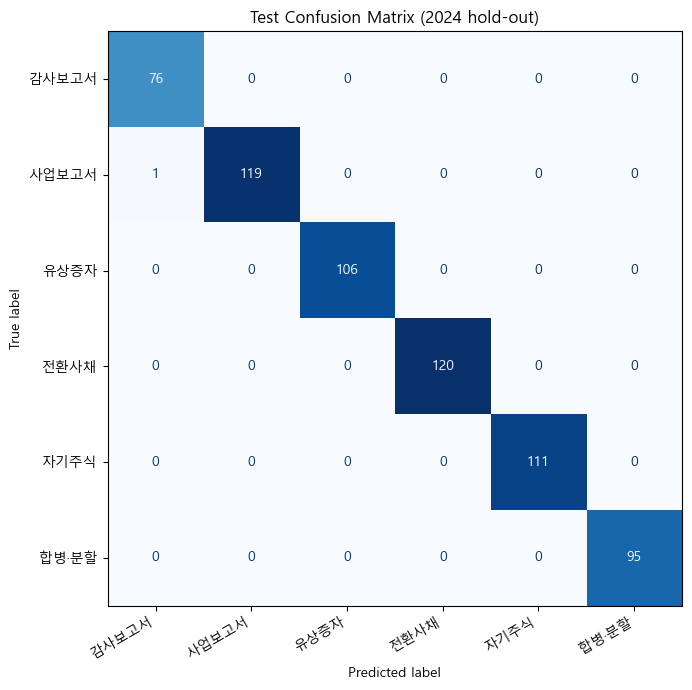

In [16]:
# 혼동 행렬 시각화
import matplotlib.pyplot as plt
import matplotlib
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

matplotlib.rcParams["font.family"] = "Malgun Gothic"

cm = confusion_matrix(test_output.label_ids, test_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=LABEL_NAMES)

fig, ax = plt.subplots(figsize=(9, 7))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Test Confusion Matrix (2024 hold-out)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## 12. 추론 테스트

In [17]:
from transformers import pipeline

# 학습 완료된 model 객체로 직접 pipeline 구성
classifier = pipeline(
    "text-classification",
    model=model,
    tokenizer=tokenizer,
    device=0 if torch.cuda.is_available() else -1,
    truncation=True,
    max_length=512,
)

print("=== 클래스별 추론 샘플 ===")
for label in LABEL_NAMES:
    sub = test_df[test_df["label"] == label]
    if sub.empty:
        sub = val_df[val_df["label"] == label]
    sample = sub.iloc[0]
    result = classifier(sample["text"])[0]
    ok = "✅" if result["label"] == label else "❌"
    print(f"\n{ok} 실제: {label}")
    print(f"   예측: {result['label']} (신뢰도: {result['score']:.3f})")
    print(f"   텍스트: {sample['text'][:80]}...")

=== 클래스별 추론 샘플 ===

✅ 실제: 감사보고서
   예측: 감사보고서 (신뢰도: 0.997)
   텍스트: 감사보고서 4.1 주식회사 수산이앤에스 00260295 100000000000 20240328 2301110180396 000 144938 30...

✅ 실제: 사업보고서
   예측: 사업보고서 (신뢰도: 0.994)
   텍스트: 사업보고서 5.5 주식회사대백저축은행 N Z N 170111-0004044 사 업 보 고 서 (제55기) 목 차 【 대표이사 등의 확인 】 대표...

✅ 실제: 유상증자
   예측: 유상증자 (신뢰도: 0.995)
   텍스트: 주요사항보고서(유상증자결정) 2.8 (주) 룽투코리아 주요사항보고서 / 거래소 신고의무 사항 유상증자 결정 ※ 기타주식에 관한 사항 20. 기타...

✅ 실제: 전환사채
   예측: 전환사채 (신뢰도: 0.995)
   텍스트: 주요사항보고서(전환사채권 발행결정) 2.7 (주)넥스턴바이오사이언스 주요사항보고서 / 거래소 신고의무 사항 금융위원회 / 한국거래소 귀중 202...

✅ 실제: 자기주식
   예측: 자기주식 (신뢰도: 0.995)
   텍스트: 주요사항보고서(자기주식취득 신탁계약 체결 결정) 1.5 (주)에이스토리 주요사항보고서 / 거래소 신고의무 사항 금융위원회 / 한국거래소 귀중 2...

✅ 실제: 합병·분할
   예측: 합병·분할 (신뢰도: 0.995)
   텍스트: 회사합병 결정 2.3 (주)이랜드인베스트 회사합병 결정 기업집단명 이랜드 회사명 ㈜이랜드인베스트 공시일자 2024.03.15 관련법규 공정거래법...


## 13. 모델 저장

In [18]:
import os

os.makedirs(SAVE_DIR, exist_ok=True)

model.save_pretrained(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)

print(f"모델 저장 완료: {SAVE_DIR}")
print()
print("저장된 파일:")
for f in os.listdir(SAVE_DIR):
    size = os.path.getsize(os.path.join(SAVE_DIR, f))
    print(f"  {f} ({size/1024/1024:.1f} MB)")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

모델 저장 완료: ./models/dart_new_classifier

저장된 파일:
  config.json (0.0 MB)
  model.safetensors (422.0 MB)
  tokenizer.json (0.7 MB)
  tokenizer_config.json (0.0 MB)


## 14. 저장된 모델로 최종 검증

실제 서비스에서 로드되는 방식과 동일하게 테스트합니다.

In [19]:
from transformers import pipeline

# 저장된 모델 파일에서 로드 (서비스와 동일한 방식)
test_classifier = pipeline(
    "text-classification",
    model=SAVE_DIR,
    tokenizer=SAVE_DIR,
    device=-1,           # CPU로 로드 (서비스 환경)
    truncation=True,
    max_length=512,
)

# 클래스별 1건씩 검증
print("=== 저장 모델 최종 검증 ===")
all_ok = True
for label in LABEL_NAMES:
    sub = test_df[test_df["label"] == label]
    if sub.empty:
        sub = val_df[val_df["label"] == label]
    sample = sub.iloc[0]
    result = test_classifier(sample["text"])[0]
    ok = result["label"] == label
    all_ok = all_ok and ok
    print(f"  {'✅' if ok else '❌'} [{label}] → 예측: {result['label']} ({result['score']:.3f})")

print()
if all_ok:
    print("✅ 모든 클래스 정상 — 서비스 배포 준비 완료")
else:
    print("❌ 일부 클래스 오분류 — 데이터 보강 또는 하이퍼파라미터 조정 필요")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

=== 저장 모델 최종 검증 ===
  ✅ [감사보고서] → 예측: 감사보고서 (0.997)
  ✅ [사업보고서] → 예측: 사업보고서 (0.994)
  ✅ [유상증자] → 예측: 유상증자 (0.995)
  ✅ [전환사채] → 예측: 전환사채 (0.995)
  ✅ [자기주식] → 예측: 자기주식 (0.995)
  ✅ [합병·분할] → 예측: 합병·분할 (0.995)

✅ 모든 클래스 정상 — 서비스 배포 준비 완료


---

## ✅ 완료 후 다음 단계

`models/dart_new_classifier/` 가 정상 저장되면 서비스 코드를 업데이트합니다.

### `core/config.py` 수정
```python
# 기존
CLASSIFIER_MODEL_DIR = str(BASE_DIR / "models" / "dart_classifier")
LABEL_NAMES = ["감사보고서", "사업보고서", "유상증자"]

# 변경
CLASSIFIER_MODEL_DIR = str(BASE_DIR / "models" / "dart_new_classifier")
LABEL_NAMES = ["감사보고서", "사업보고서", "유상증자", "전환사채", "자기주식", "합병·분할"]
```

### `services/classifier.py` 수정
```python
# max_length 512로 수정 (버그 수정)
_classifier = pipeline(..., max_length=512, ...)
def classify_text(text: str):
    return classifier(text)[0]   # text[:512] 슬라이싱 제거
```

### `services/disclosure.py` 수정
```python
# REPORT_NM_MAP에 신규 3클래스 키워드 추가
"전환사채":  "전환사채",
"교환사채":  "전환사채",
"자기주식":  "자기주식",
"합병":      "합병·분할",
"분할":      "합병·분할",
```